In [62]:
import scipy.signal as sg
import numpy as np
def fourier_tr_padding(x, y):
    N = len(x)
    offset_init = np.mean(y)
    y_n = y - offset_init
    n_padding = 100
    freq_fft = np.fft.fftfreq(N*n_padding, (x[1]-x[0]))
    data_fft = np.fft.fft(np.concatenate([y_n, [0]*N*(n_padding-1)]))
    sorted_idx = np.argsort(freq_fft)
    freq_fft = freq_fft[sorted_idx]
    data_fft = data_fft[sorted_idx]
    return freq_fft, data_fft

def fourier_tr(x, y):
    y_n = y - np.mean(y)
    N = len(x)
    dt = x[1] - x[0]
    freq_fft = np.fft.fftfreq(N, dt)
    data_fft = np.fft.fft(y_n)
    sorted_idx = np.argsort(freq_fft)
    freq_fft = freq_fft[sorted_idx]
    data_fft = data_fft[sorted_idx]
    return freq_fft, data_fft

def start_stop(x, y, xstart, xstop):
    x_list = np.array([el for el in x if el>=xstart and el<=xstop])
    x_idx = [i for i, el in enumerate(x) if el>=xstart and el<=xstop]
    y_list = y[x_idx]
    return x_list, y_list

def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y

def demodulate(t, data, demodulation_if = 0.125):
    return (data * np.exp(2j * np.pi * demodulation_if * t)).mean(axis=-1)

# spatiotempioral mode

secant hyperbolic function

Z_m 2.3561944901923456e-06 1 [0.0, 1.0]
Z_m 2.2089323345553242e-10 2 [-3333.3333333333326, 0.0, 1.0]
Z_m 9.54476934684399e-15 3 [0.0, -13999.999999999998, 0.0, 1.0]
Z_m 2.348908081449889e-19 4 [77142857.14285716, 0.0, -37142.85714285715, 0.0, 1.0]
Z_m 3.7206704010166296e-24 5 [0.0, 646031746.0317459, 0.0, -77777.77777777778, 0.0, 1.0]
Z_m 4.1053693468007393e-29 6 [-4870129870129.864, 0.0, 2990909090.909087, 0.0, -140909.0909090908, 0.0, 1.0]
Z_m 3.3342233345529004e-34 7 [0.0, -63419580419580.66, 0.0, 10039860139.86017, 0.0, -231538.46153846185, 0.0, 1.0]


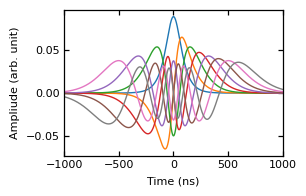

In [63]:
from scipy.special import gamma, zeta
import matplotlib.pyplot as plt

kappa = 2.5e-3*2*np.pi*2

def N_m(m, kappa=kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

# A_list[m] has the coefficients of A_m(t)([a0, a1, ..., am] (t^0, t^1, ..., t^m))
A_list = {}
Z_list = {}

A_list[0] = [1.0]
Z_dict = {
    0: kappa / 4,
    }

def compute_Z_m(m, A_coeffs):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = N_m(Nj_index)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1/Z

def get_A_m(m):
    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = get_A_m(lower_m)

        # sum over j
        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = N_m(m - (i + j))
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = compute_Z_m(m, A_m_coeffs)
    print("Z_m", Z_m, m, A_m_coeffs)
    Z_dict[m] = Z_m

    A_list[m] = A_m_coeffs
    return A_m_coeffs

def sech(x):
    return 1 / np.cosh(x)

def xi_m(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))

for m in range(8):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (arb. unit)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_25.pdf")
plt.show()

In [65]:
def transmissivity(omega, omega_0, linewidth):
    gamma = linewidth
    delta = omega - omega_0
    return 1 / (1 + (2 * delta / gamma)**2)

from scipy.integrate import simpson

In [66]:
class FourierCache:
    def __init__(self, t_vals, kappa, omega_0, readout_lo_freq, target_freq, n_max):
        self.t_vals = t_vals
        self.kappa = kappa
        self.omega_0 = omega_0
        self.readout_lo_freq = readout_lo_freq
        self.target_freq = target_freq
        self.n_max = n_max
        self.cache = dict()

    def get_fourier(self, m, delta_freq=0.0, freq_bin=False):
        key = (m, delta_freq, freq_bin)
        if key in self.cache:
            return self.cache[key]
        
        if freq_bin:
            xi = xi_m_freqbin(self.t_vals, m, delta_freq, self.kappa, n_max=self.n_max)
        else:
            xi = xi_m(self.t_vals, m, self.kappa)

        xi = xi.astype(np.complex128)  
        xi *= np.exp(-2j * np.pi * self.t_vals * (self.readout_lo_freq - self.target_freq))

        freq_axis, fourier = fourier_tr(self.t_vals, xi)
        photon_freq = self.readout_lo_freq + freq_axis
        
        self.cache[key] = (photon_freq, fourier)
        return photon_freq, fourier

def inner_product_freq(m1, m2, fourier_cache, linewidth, freq_bin=False, delta_freq=0.0):
    photon_freq_1, fourier1 = fourier_cache.get_fourier(m1, delta_freq, freq_bin)
    photon_freq_2, fourier2 = fourier_cache.get_fourier(m2, delta_freq, freq_bin)
    assert np.allclose(photon_freq_1, photon_freq_2)
    photon_freq = photon_freq_1

    T = transmissivity(photon_freq, fourier_cache.omega_0, linewidth)

    inner_prod_filtered = simpson(np.conj(fourier1 * T) * (fourier2 * T), x=photon_freq) / (2 * np.pi)
    power_filter_1 = simpson(np.abs(fourier1 * T)**2, x=photon_freq) / (2 * np.pi)
    power_filter_2 = simpson(np.abs(fourier2 * T)**2, x=photon_freq) / (2 * np.pi)
    norm_factor = np.sqrt(power_filter_1 * power_filter_2)

    return inner_prod_filtered / norm_factor


In [68]:
readout_lo_freq = 9.5
target_freq = 9.38
duration = 4000
t_vals = np.linspace(-duration/2, duration/2, duration*10)
fourier_cache = FourierCache(t_vals, kappa, omega_0, readout_lo_freq, target_freq, n_max=n_max)

In [69]:
# def inner_product_freq_old(m1, m2, kappa, t_vals, omega_0, linewidth, freq_bin=False, delta_freq=0.002, n_max=10):
#     if freq_bin:
#         xi1 = xi_m_freqbin(t_vals, m1, delta_freq, kappa, n_max) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
#         xi2 = xi_m_freqbin(t_vals, m2, delta_freq, kappa, n_max) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
#     else:
#         xi1 = xi_m(t_vals, m1, kappa) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
#         xi2 = xi_m(t_vals, m2, kappa) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))

#     xfft1, fourier1 = fourier_tr(t_vals, xi1)
#     xfft2, fourier2 = fourier_tr(t_vals, xi2)
#     assert np.allclose(xfft1, xfft2)
#     photon_freq = readout_lo_freq + xfft1

#     T = transmissivity(photon_freq, omega_0, linewidth)

#     # power_no_filter_1 = simpson(np.abs(fourier1) ** 2, x=photon_freq) / (2 * np.pi)
#     # power_no_filter_2 = simpson(np.abs(fourier2) ** 2, x=photon_freq) / (2 * np.pi)
#     # norm_factor_filter = np.sqrt(power_no_filter_1 * power_no_filter_2)

#     inner_prod_filtered = simpson(np.conj(fourier1 * T) * (fourier2 * T), x=photon_freq) / (2 * np.pi)

#     power_filter_1 = simpson(np.abs(fourier1 * T) ** 2, x=photon_freq) / (2 * np.pi)
#     power_filter_2 = simpson(np.abs(fourier2 * T) ** 2, x=photon_freq) / (2 * np.pi)
#     norm_factor = np.sqrt(power_filter_1 * power_filter_2)

#     # return inner_prod_filtered / norm_factor_filter
#     return inner_prod_filtered / norm_factor


# def norm_of_xi_freq(m, kappa, t_vals, omega_0, linewidth, freq_bin=False, delta_freq=0.002):
#     if freq_bin:
#         xi = xi_m_freqbin(t_vals, m, delta_freq, kappa) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
#     else:
#         xi = xi_m(t_vals, m, kappa) * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
#     xfft, fourier = fourier_tr(t_vals, xi)
#     photon_freq = readout_lo_freq + xfft

#     T = transmissivity(photon_freq, omega_0, linewidth)
#     power_spectrum = np.abs(fourier * T) ** 2
#     norm_sq = simpson(power_spectrum, x=photon_freq) / (2 * np.pi)
#     return np.sqrt(norm_sq)

def compute_separability(I_normalized):
    M = I_normalized.shape[0]
    S_list = []
    for m in range(M):
        numerator = np.abs(I_normalized[m, m])**2
        denominator = np.sum(np.abs(I_normalized[m, :])**2)
        S_list.append(numerator / denominator)
    return np.mean(S_list)

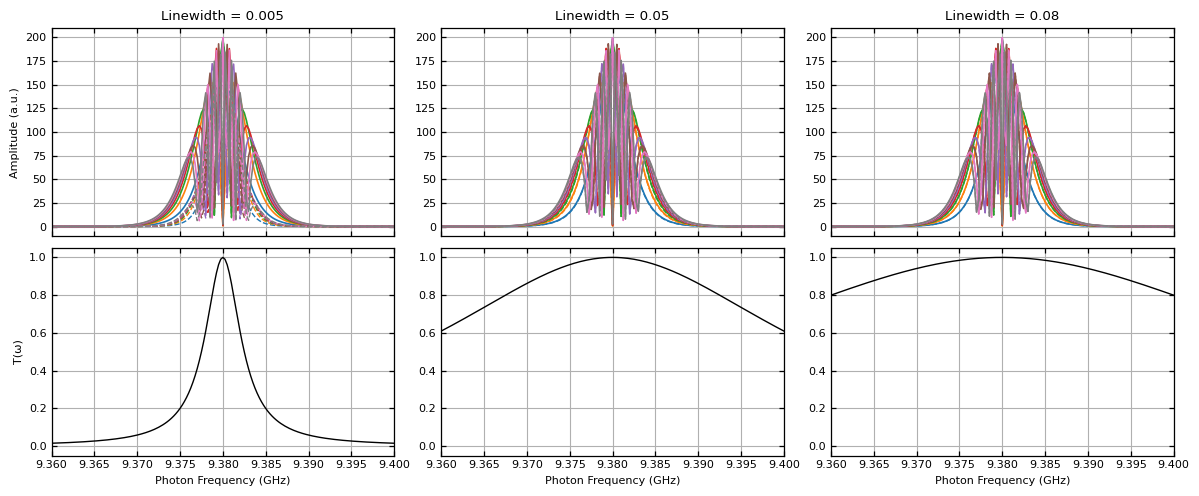

C:\Users\qipe\AppData\Local\Temp\ipykernel_10020\1073579894.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix[m1, m2] = gram_matrix[m1, m2] = inner_product_freq(


Linewidth = 0.005: Separability = 0.7723
Linewidth = 0.05: Separability = 0.9997
Linewidth = 0.08: Separability = 0.9999


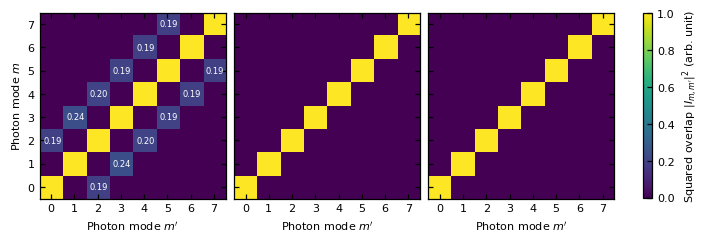

In [70]:
n_max = 7
linewidths = [0.005, 0.05, 0.08]

colors = plt.cm.tab10.colors 
omega_0 = target_freq

fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)

for idx, linewidth in enumerate(linewidths):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    for m in range(n_max + 1):
        waveform = xi_m(t_vals, m, kappa)
        waveform_shifted = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
        xfft, fourier = fourier_tr(t_vals, waveform_shifted)
        photon_freq = readout_lo_freq + xfft

        T = transmissivity(photon_freq, omega_0=target_freq, linewidth=linewidth)

        ax_spec.plot(photon_freq, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(photon_freq, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}")
    ax_spec.set_xlim(9.36, 9.4)
    ax_spec.grid(True)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (a.u.)")

    ax_T.plot(photon_freq, T, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    if idx == 0:
        ax_T.set_ylabel("T(ω)")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, linewidth in enumerate(linewidths):
    gram_matrix = np.zeros((n_max + 1, n_max + 1))
    I_normalized = np.zeros((n_max + 1, n_max + 1))
    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = gram_matrix[m1, m2] = inner_product_freq(
                m1, m2, fourier_cache, linewidth,
                freq_bin=False
            )
            I_normalized[m1, m2] = gram_matrix[m1, m2] #/ norm_product

    separability = compute_separability(I_normalized)
    print(f"Linewidth = {linewidth}: Separability = {separability:.4f}")

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            text = f"{(I_normalized[i, j]**2):.2f}"
            if I_normalized[i, j]**2 > 0.1 and I_normalized[i, j]**2 < 0.99:
                if I_normalized[i, j]**2 > 0.5:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='red', fontsize=6)
                else:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='white', fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
# plt.savefig("Figapp3_a_25.pdf", bbox_inches='tight')
plt.show()

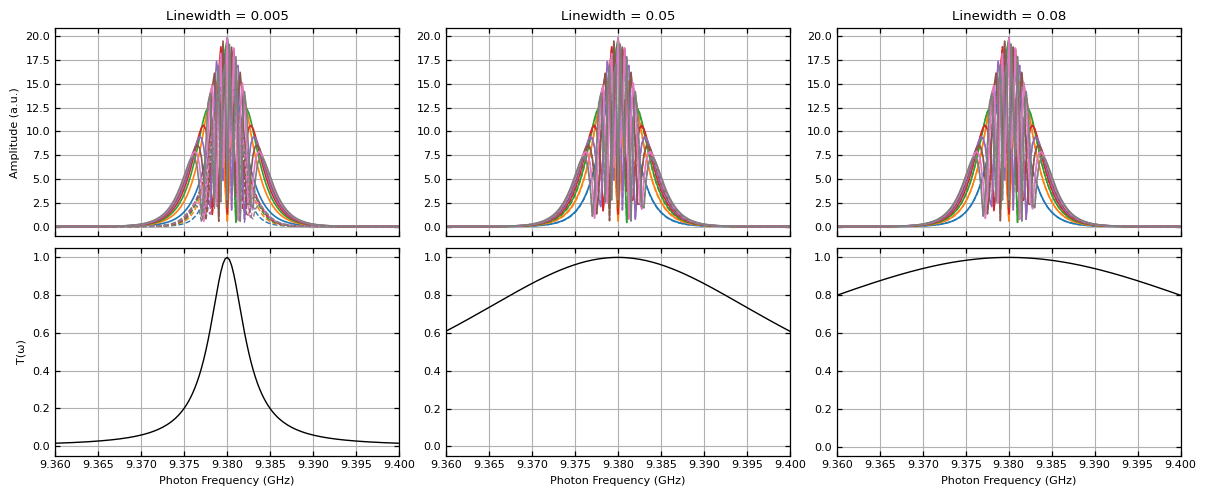

C:\Users\qipe\AppData\Local\Temp\ipykernel_10020\481567288.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix[m1, m2] = gram_matrix[m1, m2] = inner_product_freq_old(


Linewidth = 0.005: Separability = 0.7723
Linewidth = 0.05: Separability = 0.9997
Linewidth = 0.08: Separability = 0.9999


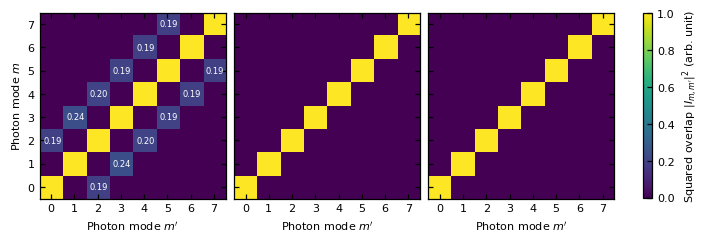

In [ ]:
n_max = 7
linewidths = [0.02, 0.05, 0.08]

colors = plt.cm.tab10.colors 
omega_0 = target_freq

fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)

for idx, linewidth in enumerate(linewidths):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    for m in range(n_max + 1):
        waveform = xi_m(t_vals, m, kappa)
        waveform_shifted = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
        xfft, fourier = fourier_tr(t_vals, waveform_shifted)
        photon_freq = readout_lo_freq + xfft

        T = transmissivity(photon_freq, omega_0=target_freq, linewidth=linewidth)

        ax_spec.plot(photon_freq, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(photon_freq, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}")
    ax_spec.set_xlim(9.36, 9.4)
    ax_spec.grid(True)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (a.u.)")

    ax_T.plot(photon_freq, T, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    if idx == 0:
        ax_T.set_ylabel("T(ω)")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, linewidth in enumerate(linewidths):
    gram_matrix = np.zeros((n_max + 1, n_max + 1))
    I_normalized = np.zeros((n_max + 1, n_max + 1))
    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = gram_matrix[m1, m2] = inner_product_freq_old(
                m1, m2,  kappa, t_vals, omega_0, linewidth,
                freq_bin=False
            )
            I_normalized[m1, m2] = gram_matrix[m1, m2] #/ norm_product

    separability = compute_separability(I_normalized)
    print(f"Linewidth = {linewidth}: Separability = {separability:.4f}")

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            text = f"{(I_normalized[i, j]**2):.2f}"
            if I_normalized[i, j]**2 > 0.1 and I_normalized[i, j]**2 < 0.99:
                if I_normalized[i, j]**2 > 0.5:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='red', fontsize=6)
                else:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='white', fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
# plt.savefig("Figapp3_a_25.pdf", bbox_inches='tight')
plt.show()

frequency bin

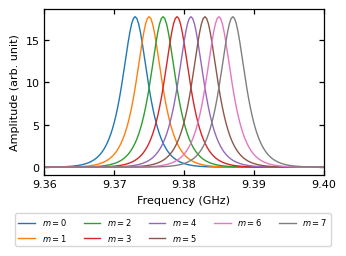

In [49]:
from scipy.fft import fft, fftfreq, fftshift

dt = t_vals[1] - t_vals[0]

delta_freq = 0.002 
omega_0 = 9.38
def xi_m_freqbin(t, m, delta_freq, kappa, n_max):
    t = np.asarray(t, dtype=np.float64)
    base_waveform = np.asarray(xi_m(t, 0, kappa), dtype=np.complex128)
    center = n_max / 2

    freq_shift = float(delta_freq * (m - center))
    phase = np.exp(2j * np.pi * freq_shift * t)

    return base_waveform * phase

xi_funcs_f = []
freq_axis = fftshift(fftfreq(len(t_vals), dt))+ omega_0 
for m in range(n_max+1):
    xi_t = xi_m_freqbin(t_vals, m, delta_freq, kappa, n_max)
    xi_f = fftshift(fft(xi_t))
    xi_funcs_f.append(np.abs(xi_f))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.2))
for m, spectrum in enumerate(xi_funcs_f):
    ax.plot(freq_axis, spectrum, label=f"$m={m}$")

ax.set_xlim(9.36, 9.4) 
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Amplitude (arb. unit)")
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=6)

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 0.9
plt.rcParams['ytick.major.width'] = 0.9
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.9
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.tight_layout()
plt.show()


In [33]:
def find_delta_freq_for_all_modes(
    omega_0, linewidth, t_vals, kappa,
    n_modes=n_max+1,
    delta_range=(1e-5, 0.02), fidelity_threshold=0.9, num_points=100,
    plot=True
):
    dt = t_vals[1] - t_vals[0]
    fft_axis = fftshift(fftfreq(len(t_vals), dt)) + omega_0
    T_freq = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)

    delta_freqs = np.linspace(delta_range[0], delta_range[1], num_points)
    all_fidelities = np.zeros((n_modes, num_points))

    for m in range(n_modes):
        for i, delta_freq in enumerate(delta_freqs):
            xi = xi_m_freqbin(t_vals, m, delta_freq, kappa)
            Xi_freq = fftshift(fft(xi))

            norm_original = np.trapz(np.abs(Xi_freq)**2, x=fft_axis)
            norm_transmitted = np.trapz(np.abs(Xi_freq * T_freq)**2, x=fft_axis)
            fidelity = norm_transmitted / norm_original
            all_fidelities[m, i] = fidelity

    fidelities_min_across_modes = np.min(all_fidelities, axis=0)
    above_threshold = np.where(fidelities_min_across_modes >= fidelity_threshold)[0]

    if len(above_threshold) == 0:
        raise RuntimeError("No delta_freq satisfies the fidelity threshold for all modes.")

    max_idx = above_threshold[-1]
    best_delta_freq = delta_freqs[max_idx]
    if plot:
        plt.figure(figsize=(6, 4))
        for m in range(n_modes):
            plt.plot(delta_freqs, all_fidelities[m], label=f"mode {m}")
        plt.axhline(fidelity_threshold, color='gray', linestyle='--', label='Threshold = 0.9')
        plt.axvline(best_delta_freq, color='red', linestyle='--', label=f'Max Δf = {best_delta_freq:.5f} GHz')
        plt.xlabel("Delta frequency (GHz)")
        plt.ylabel(r"Fidelity $|I_{mm}|^2$")
        plt.title(f"Fidelity vs delta_freq (linewidth = {linewidth})")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    print(f"✅ Best delta_freq = {best_delta_freq:.6f} GHz (for all m, fidelity ≥ {fidelity_threshold})")
    return best_delta_freq


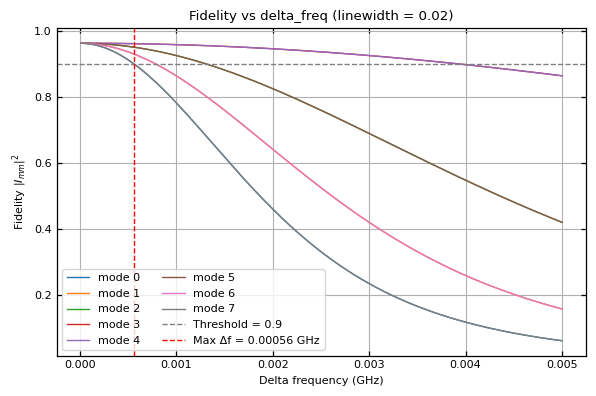

✅ Best delta_freq = 0.000562 GHz (for all m, fidelity ≥ 0.9)


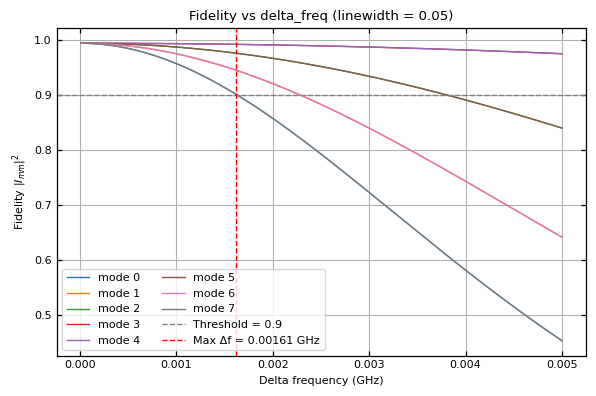

✅ Best delta_freq = 0.001615 GHz (for all m, fidelity ≥ 0.9)


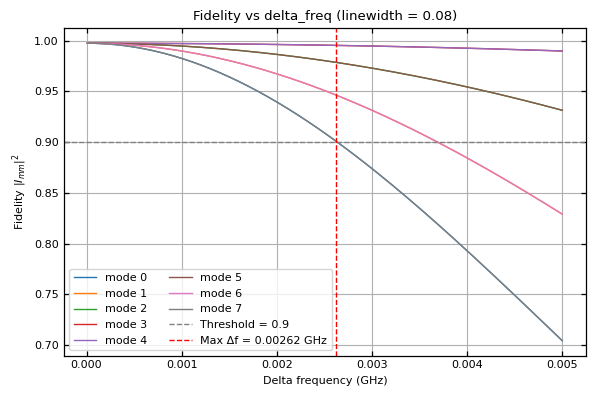

✅ Best delta_freq = 0.002618 GHz (for all m, fidelity ≥ 0.9)


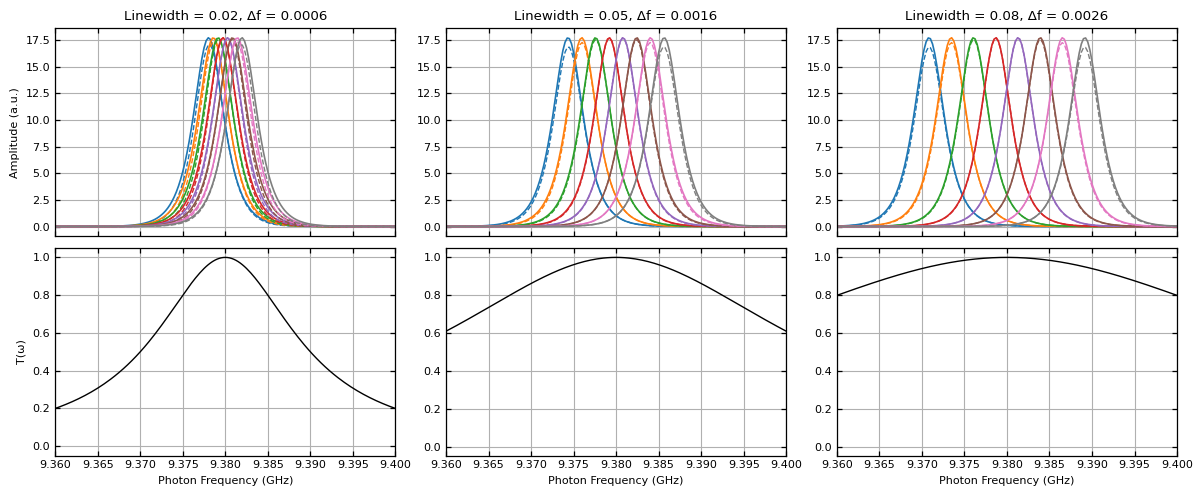

C:\Users\qipe\AppData\Local\Temp\ipykernel_7984\315774634.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  I_normalized[m1, m2] = gram_matrix[m1, m2]  # / norm_product


Linewidth = 0.02: Separability = 0.1716
Linewidth = 0.05: Separability = 0.3621
Linewidth = 0.08: Separability = 0.5449


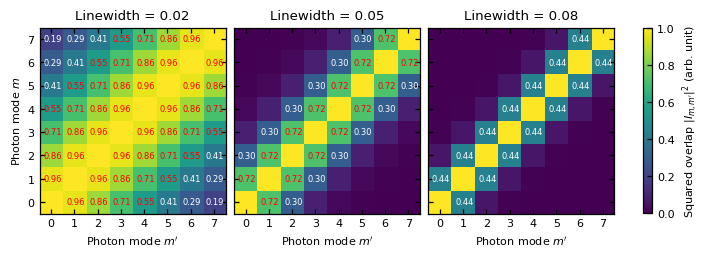

In [52]:

colors = plt.cm.tab10.colors

best_delta_freqs = []
for linewidth in linewidths:
    best_df = find_delta_freq_for_all_modes(
        omega_0=omega_0,
        linewidth=linewidth,
        t_vals=t_vals,
        kappa=kappa,
        delta_range=(1e-5, 0.005),
        fidelity_threshold=0.9,
        num_points=200
    )
    best_delta_freqs.append(best_df)

fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)
fft_axis = fftshift(fftfreq(len(t_vals), dt)) + omega_0

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    for m in range(n_max + 1):
        waveform = xi_m_freqbin(t_vals, m, delta_freq, kappa)
        fourier = fftshift(fft(waveform))
        T = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)

        ax_spec.plot(fft_axis, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(fft_axis, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}, Δf = {delta_freq:.4f}")
    ax_spec.set_xlim(omega_0 - 0.02, omega_0 + 0.02)
    ax_spec.grid(True)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (a.u.)")

    T_plot = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)
    ax_T.plot(fft_axis, T_plot, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    if idx == 0:
        ax_T.set_ylabel("T(ω)")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(linewidths), figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    gram_matrix = np.zeros((n_max + 1, n_max + 1), dtype=complex)
    I_normalized = np.zeros((n_max + 1, n_max + 1))

    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = inner_product_freq(
                m1, m2, kappa, t_vals, omega_0, linewidth,
                freq_bin=True, delta_freq=delta_freq
            )
            # norm_product = (
            #     norm_of_xi_freq(m1, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq) *
            #     norm_of_xi_freq(m2, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq)
            # )
            I_normalized[m1, m2] = gram_matrix[m1, m2]  # / norm_product 

    separability = compute_separability(I_normalized)
    print(f"Linewidth = {linewidth}: Separability = {separability:.4f}")

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    ax.set_title(f"Linewidth = {linewidth}")
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            val = I_normalized[i, j]**2
            if 0.1 < val < 0.99:
                color = 'red' if val > 0.5 else 'white'
                ax.text(j + 0.05, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
plt.show()


0.0033333333333333335
0.008333333333333333
0.013333333333333334


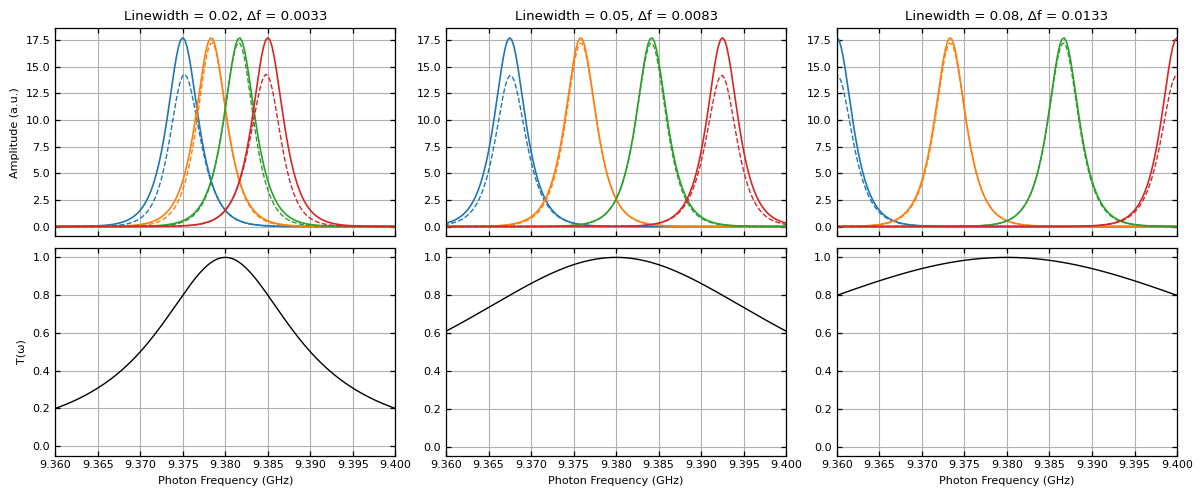

TypeError: inner_product_freq() got multiple values for argument 'freq_bin'

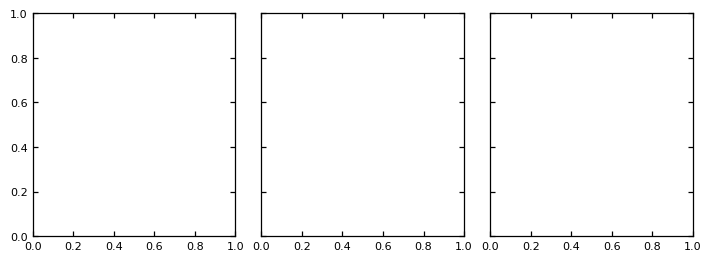

In [18]:
colors = plt.cm.tab10.colors
linewidths = [0.02, 0.05, 0.08]
n_max=3
best_delta_freqs = []
def delta_freq_by_halfwidth_partition(linewidth, n_max, coverage=1.0):
    total_bandwidth = coverage * linewidth
    delta_freq = total_bandwidth / n_max/2
    return delta_freq

for linewidth in linewidths:
    best_df = delta_freq_by_halfwidth_partition(linewidth, n_max)
    print(best_df)
    best_delta_freqs.append(best_df)
fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)
fft_axis = fftshift(fftfreq(len(t_vals), dt)) + omega_0

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    for m in range(n_max + 1):
        waveform = xi_m_freqbin(t_vals, m, delta_freq, kappa, n_max=n_max)
        fourier = fftshift(fft(waveform))
        T = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)

        ax_spec.plot(fft_axis, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(fft_axis, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}, Δf = {delta_freq:.4f}")
    ax_spec.set_xlim(omega_0 - 0.02, omega_0 + 0.02)
    ax_spec.grid(True)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (a.u.)")

    T_plot = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)
    ax_T.plot(fft_axis, T_plot, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    if idx == 0:
        ax_T.set_ylabel("T(ω)")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(linewidths), figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    gram_matrix = np.zeros((n_max + 1, n_max + 1), dtype=complex)
    I_normalized = np.zeros((n_max + 1, n_max + 1))

    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = inner_product_freq(
                m1, m2, kappa, t_vals, omega_0, linewidth,
                freq_bin=True, delta_freq=delta_freq
            )
            # norm_product = (
            #     norm_of_xi_freq(m1, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq) *
            #     norm_of_xi_freq(m2, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq)
            # )
            I_normalized[m1, m2] = gram_matrix[m1, m2]  # / norm_product 

    separability = compute_separability(I_normalized)
    print(f"Linewidth = {linewidth}: Separability = {separability:.4f}")

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    ax.set_title(f"Linewidth = {linewidth}")
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            val = I_normalized[i, j]**2
            if 0.1 < val < 0.99:
                color = 'red' if val > 0.5 else 'white'
                ax.text(j + 0.05, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
plt.show()


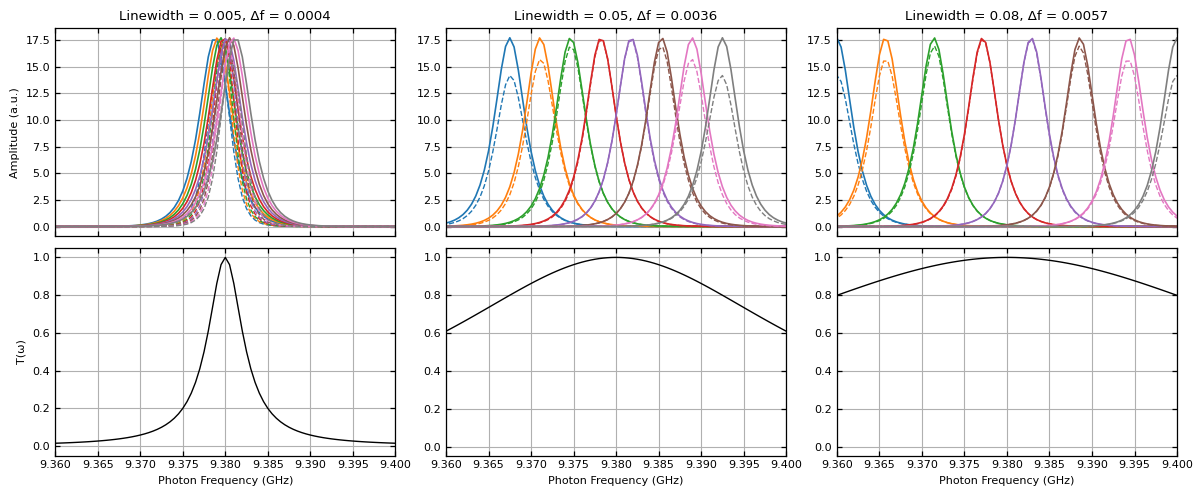

C:\Users\qipe\AppData\Local\Temp\ipykernel_10020\2606454837.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  I_normalized[m1, m2] = gram_matrix[m1, m2]  # / norm_product


Linewidth = 0.005: Separability = 0.1457
Linewidth = 0.05: Separability = 0.7014
Linewidth = 0.08: Separability = 0.9319


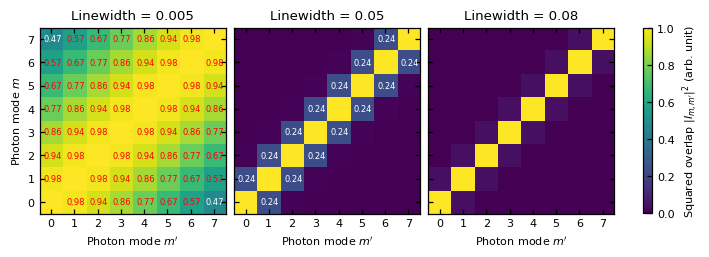

In [ ]:
linewidths = [0.02, 0.05, 0.08]

best_delta_freqs = []
for linewidth in linewidths:
    best_df = delta_freq_by_halfwidth_partition(linewidth, n_max)
    best_delta_freqs.append(best_df)

fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)
fft_axis = fftshift(fftfreq(len(t_vals), dt)) + omega_0


for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    for m in range(n_max + 1):
        waveform = xi_m_freqbin(t_vals, m, delta_freq, kappa, n_max=n_max)
        fourier = fftshift(fft(waveform))
        T = transmissivity(fft_axis, omega_0=omega_0, linewidth=linewidth)

        ax_spec.plot(fft_axis, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(fft_axis, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}, Δf = {delta_freq:.4f}")
    ax_spec.set_xlim(omega_0 - 0.02, omega_0 + 0.02)
    ax_spec.grid(True)
    if idx == 0:
        ax_spec.set_ylabel("Amplitude (a.u.)")

    ax_T.plot(fft_axis, T, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    if idx == 0:
        ax_T.set_ylabel("T(ω)")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(linewidths), figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    fourier_cache = FourierCache(t_vals, kappa, omega_0, readout_lo_freq, target_freq, n_max)
    gram_matrix = np.zeros((n_max + 1, n_max + 1), dtype=complex)
    I_normalized = np.zeros((n_max + 1, n_max + 1))

    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = inner_product_freq(
                m1, m2, fourier_cache,  kappa,
                freq_bin=True, delta_freq=delta_freq
            )
            # norm_product = (
            #     norm_of_xi_freq(m1, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq) *
            #     norm_of_xi_freq(m2, kappa, t_vals, omega_0, linewidth, freq_bin=True, delta_freq=delta_freq)
            # )
            I_normalized[m1, m2] = gram_matrix[m1, m2]  # / norm_product 

    separability = compute_separability(I_normalized)
    print(f"Linewidth = {linewidth}: Separability = {separability:.4f}")

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    ax.set_title(f"Linewidth = {linewidth}")
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            val = I_normalized[i, j]**2
            if 0.1 < val < 0.99:
                color = 'red' if val > 0.5 else 'white'
                ax.text(j + 0.05, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
plt.show()


In [59]:
def plot_fouriercache_spectrum_freqbin(fourier_cache, linewidth, delta_freq, n_max, ax_spec, ax_T, colors, freq_xlim=None):
    for m in range(n_max + 1):
        # freq_bin=True, delta_freq≠0 に注目
        photon_freq, fourier = fourier_cache.get_fourier(m, delta_freq=delta_freq, freq_bin=True)

        T = transmissivity(photon_freq, omega_0=fourier_cache.target_freq, linewidth=linewidth)

        ax_spec.plot(photon_freq, np.abs(fourier), label=f"Mode {m}", color=colors[m % len(colors)], linewidth=1.2)
        ax_spec.plot(photon_freq, np.abs(fourier * T), linestyle='--', color=colors[m % len(colors)], linewidth=1.0)

    ax_spec.set_title(f"Linewidth = {linewidth}, Δf = {delta_freq:.4f}")
    if freq_xlim:
        ax_spec.set_xlim(*freq_xlim)
    ax_spec.grid(True)
    ax_spec.set_ylabel("Amplitude (a.u.)")

    ax_T.plot(photon_freq, T, color='black')
    ax_T.set_xlabel("Photon Frequency (GHz)")
    ax_T.grid(True)
    ax_T.set_ylabel("T(ω)")


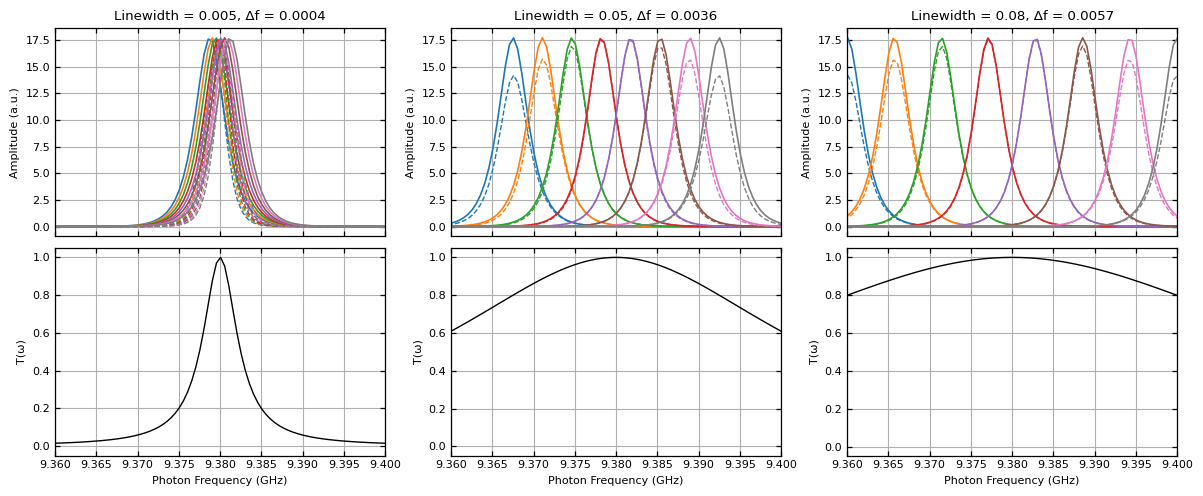

In [60]:
fig, axs = plt.subplots(2, len(linewidths), figsize=(4 * len(linewidths), 5), sharex=True)

for idx, (linewidth, delta_freq) in enumerate(zip(linewidths, best_delta_freqs)):
    ax_spec = axs[0, idx]
    ax_T = axs[1, idx]

    # FourierCache インスタンスの生成（n_max は共通の最大次数）
    fourier_cache = FourierCache(t_vals, kappa, omega_0, readout_lo_freq, target_freq, n_max)

    # プロット
    plot_fouriercache_spectrum_freqbin(
        fourier_cache, linewidth, delta_freq, n_max, ax_spec, ax_T, colors,
        freq_xlim=(omega_0 - 0.02, omega_0 + 0.02)  # 表示範囲を揃える
    )

plt.tight_layout()
plt.show()


2D plot

In [21]:
bandwidth_list = np.linspace(0.0, 0.01, 11)
m_range = np.arange(1, 19)
duration = 4000

best_delta_freqs = []
for m in m_range:
    best_delta_freqs_m = []
    for bandwidth in bandwidth_list:
        best_df = delta_freq_by_halfwidth_partition(bandwidth, m)
        best_delta_freqs_m.append(best_df)
    best_delta_freqs.append(best_delta_freqs_m)

In [22]:
epsilon_s_map = np.zeros((len(m_range), len(bandwidth_list)))
epsilon_f_map = np.zeros((len(m_range), len(bandwidth_list)))

for i, m_tot in enumerate(m_range):
    delta_freqs = best_delta_freqs[i]
    for j, bandwidth in enumerate(bandwidth_list):
        if np.isclose(bandwidth, 0):
            epsilon_s = 0
            epsilon_f = 0
        else:
            # xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
            delta_freq = delta_freqs[j]
            # xi_funcs_f = [xi_m_freqbin(t_vals, m, delta_freq, kappa) for m in range(m_tot)]

            gram_matrix_s = np.zeros((m_tot + 1, m_tot + 1))
            I_normalized_s = np.zeros((m_tot + 1, m_tot + 1))
            for m1 in range(m_tot + 1):
                for m2 in range(m_tot + 1):
                    gram_matrix_s[m1, m2] = inner_product_freq(m1, m2, fourier_cache, linewidth, freq_bin=False, n_max=m_tot)
                    I_normalized_s[m1, m2] = gram_matrix_s[m1, m2]

            gram_matrix_f = np.zeros((m_tot + 1, m_tot + 1))
            I_normalized_f = np.zeros((m_tot + 1, m_tot + 1))
            for m1 in range(m_tot + 1):
                for m2 in range(m_tot + 1):
                    gram_matrix_f[m1, m2] = inner_product_freq(m1, m2, fourier_cache, linewidth, freq_bin=True, delta_freq=delta_freq, n_max=m_tot)

                    I_normalized_f[m1, m2] = gram_matrix_f[m1, m2]

            epsilon_s = compute_separability(I_normalized_s) 
            epsilon_f = compute_separability(I_normalized_f) 

        epsilon_s_map[i, j] = epsilon_s
        epsilon_f_map[i, j] = epsilon_f



C:\Users\qipe\AppData\Local\Temp\ipykernel_10020\247957413.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix_s[m1, m2] = inner_product_freq(m1, m2, fourier_cache, linewidth, freq_bin=False, n_max=m_tot)
C:\Users\qipe\AppData\Local\Temp\ipykernel_10020\247957413.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix_f[m1, m2] = inner_product_freq(m1, m2, fourier_cache, linewidth, freq_bin=True, delta_freq=delta_freq, n_max=m_tot)


Z_m 2.0757493904076642e-39 8 [5.99650349650344e+17, 0.0, -431684848484845.1, 0.0, 27389743589.743458, 0.0, -354666.666666666, 0.0, 1.0]
Z_m 1.0218976575242988e-44 9 [0.0, 1.0786575894693693e+19, 0.0, -2044361990950247.5, 0.0, 64581176470.588585, 0.0, -515294.1176470599, 0.0, 1.0]
Z_m 4.077371653521792e-50 10 [-1.2180513758686839e+23, 0.0, 9.847339604667594e+19, 0.0, -7607956656346659.0, 0.0, 136623529411.76384, 0.0, -718421.0526315769, 0.0, 1.0]
Z_m 1.345106556007919e-55 11 [0.0, -2.825207617460148e+24, 0.0, 6.108448223500302e+20, 0.0, -2.379371517027971e+16, 0.0, 265769924812.03833, 0.0, -969047.6190476349, 0.0, 1.0]
Z_m 3.729920282138782e-61 12 [3.6922339946360564e+28, 0.0, -3.2675083218273307e+25, 0.0, 2.9170165284693323e+21, 0.0, -6.520789931349824e+16, 0.0, 483542236024.8305, 0.0, -1272173.91304346, 0.0, 1.0]
Z_m 8.81515419784242e-67 13 [0.0, 1.0557659078707675e+30, 0.0, -2.5296166124001544e+26, 0.0, 1.1497650924485222e+22, 0.0, -1.6105146732919053e+17, 0.0, 833006086956.5013, 0.0

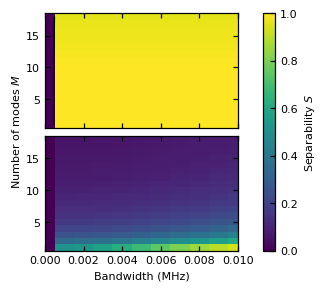

M = 8, Bandwidth = 0.005 MHz
  Spatiotemporal separability : 0.9999
  Frequency-bin separability      : 0.1293
--------------------------------------------------
M = 8, Bandwidth = 0.05 MHz
  Spatiotemporal separability : 0.9999
  Frequency-bin separability      : 0.1750
--------------------------------------------------
M = 8, Bandwidth = 0.08 MHz
  Spatiotemporal separability : 0.9999
  Frequency-bin separability      : 0.1750
--------------------------------------------------


In [39]:
X, Y = np.meshgrid(bandwidth_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0., vmax=1)
# axs[0].set_title("Spatiotemporal")
# axs[0].set_xlabel("Communication time (ns)")
# axs[0].set_ylabel("Number of modes $M$")
# fig.colorbar(c1, ax=axs[0], label=r"Basis fidelity $F(M)$")
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_f_map, shading='auto', cmap='viridis', vmin=0., vmax=1)
# axs[1].set_title("Time-bin")
axs[1].set_xlabel("Bandwidth (MHz)")
# axs[1].set_ylabel("Number of modes $M$")
fig.colorbar(c2, ax=axs, label=r"Separability $S$")
axs[0].set_xlim(0, 0.01)
axs[1].set_xlim(0, 0.01)
# # === black line ===
# target_M = 8
# target_bandwidths = [0.02, 0.05, 0.08]

# i_M = np.where(m_range == target_M)[0][0]

# for bandwidth in target_bandwidths:
#     j_dur = np.argmin(np.abs(bandwidth_list - bandwidth))
#     dur_val = bandwidth_list[j_dur]
#     for ax in axs:
#         ax.axvline(x=dur_val, color='tab:red', linestyle='--', linewidth=0.8)
#     for ax in axs:
#         ax.axhline(y=target_M, color='tab:red', linestyle='--', linewidth=0.8)
#     for ax, data_map in zip(axs, [epsilon_s_map, epsilon_f_map]):
#             value = data_map[i_M, j_dur]
#             ax.plot(dur_val, target_M, marker='o', color='tab:red', markersize=3)
# for ax in axs:
#     ax.set_yticks([0, 5, 10, 15, 20])

# === Separability = 0.95 ===

# contour_s = axs[0].contour(X-0.2, Y, epsilon_s_map, levels=[0.95], colors='black', linewidths=1.0)
# contour_t = axs[1].contour(X-0.2, Y, epsilon_t_map, levels=[0.95], colors='black', linewidths=1.0)
Xc = X[:, :-1] - np.diff(X, axis=1)/2  # center of each pcolormesh cell (x-direction)
Yc = Y[:, :-1]  # same shape as Xc (y-direction constant per row)

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_f_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# plt.savefig('Fig4_a_25.pdf', bbox_inches='tight')

plt.show()
target_M = 8
target_bandwidths = [0.005, 0.05, 0.08]

i_M = np.where(m_range == target_M)[0][0]


for bandwidth in target_bandwidths:
    j_dur = np.argmin(np.abs(bandwidth_list - bandwidth))
    
    separability_s = epsilon_s_map[i_M, j_dur]
    separability_f = epsilon_f_map[i_M, j_dur]
    
    print(f"M = {target_M}, Bandwidth = {bandwidth} MHz")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Frequency-bin separability      : {separability_f:.4f}")
    print("-" * 50)